In [5]:
from pathlib import Path
import numpy as np

folder = Path("Embeddings")

x1 = np.load(folder / "x1_shadow_train.npy", allow_pickle=False)
x2 = np.load(folder / "x2_shadow_train.npy", allow_pickle=False)
y = np.load(folder / "y_shadow_train.npy", allow_pickle=False)

assert x1.shape == x2.shape == (len(y), 768)
assert np.isfinite(x1).all() and np.isfinite(x2).all()
assert np.isin(y, [0, 1]).all()
assert not np.allclose(x1, x2), "Both embedding arrays are identical."

print("Shadow training embeddings loaded:", x1.shape)
print("Linkage label counts:", np.unique(y, return_counts=True))
print("Checks passed.")

Shadow training embeddings loaded: (32000, 768)
Linkage label counts: (array([0., 1.], dtype=float32), array([15969, 16031], dtype=int64))
Checks passed.


In [6]:
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from datetime import datetime

def build_shadow_model(dim):
    L = tf.keras.layers

    encoder_input = L.Input(shape=(dim,))
    h = L.Dense(
        50, activity_regularizer=tf.keras.regularizers.l1(0.01)
    )(encoder_input)
    h = L.LeakyReLU(alpha=0.01)(h)
    encoder = tf.keras.Model(
        encoder_input, L.Dense(dim, activation="relu")(h)
    )

    decoder_input = L.Input(shape=(dim,))
    decoder = tf.keras.Model(
        decoder_input,
        L.Dense(dim, activation="sigmoid")(decoder_input)
    )

    a, b = L.Input(shape=(dim,)), L.Input(shape=(dim,))
    combined = L.Concatenate()([
        decoder(encoder(a)), decoder(encoder(b))
    ])
    siamese = tf.keras.Model([a, b], combined)

    def loss(labels, predictions):
        left, right = predictions[:, :dim], predictions[:, dim:]
        squared_distance = tf.reduce_sum(tf.square(left - right), axis=1)
        distance = tf.sqrt(
            tf.maximum(squared_distance, tf.keras.backend.epsilon())
        )
        labels = tf.reshape(tf.cast(labels, tf.float32), [-1])
        reconstruction = tf.reduce_mean(tf.square(left - right), axis=1)
        contrastive = (
            labels * squared_distance
            + (1 - labels) * tf.square(tf.maximum(2.5 - distance, 0))
        )
        return tf.reduce_mean(reconstruction + contrastive)

    siamese.compile(optimizer="adam", loss=loss)

    head = tf.keras.Sequential([
        L.Input(shape=(dim,)),
        L.Dense(64, activation="relu"),
        L.Dense(32, activation="relu"),
        L.Dense(1, activation="sigmoid")
    ])
    head.compile(
        optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
    )
    return siamese, encoder, head

print("Model definitions ready.")

Model definitions ready.


In [7]:
K = 2
N_PAIRS = 2000
EPOCHS = 2
SEED = 42

output = Path("k_runs") / datetime.now().strftime("%Y%m%d_%H%M%S")
output.mkdir(parents=True, exist_ok=False)

# Select once; reuse the same development pool for each shadow model.
pool, _ = train_test_split(
    np.arange(len(y)),
    train_size=N_PAIRS,
    stratify=y,
    random_state=SEED
)
np.save(output / "development_pool_indices.npy", pool)
all_outputs = []

for model_number in range(1, K + 1):
    seed = SEED + model_number
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    train_idx, heldout_idx = train_test_split(
        pool, test_size=0.30, stratify=y[pool], random_state=seed
    )
    assert not np.intersect1d(train_idx, heldout_idx).size

    rng = np.random.default_rng(seed)
    n_queries = min(int(0.30 * len(train_idx)), len(heldout_idx))
    members = rng.choice(train_idx, n_queries, replace=False)
    nonmembers = rng.choice(heldout_idx, n_queries, replace=False)

    model_dir = output / f"shadow_{model_number}"
    model_dir.mkdir()
    np.savez(
        model_dir / "split_indices.npz",
        train=train_idx, heldout=heldout_idx,
        members=members, nonmembers=nonmembers
    )

    siamese, encoder, head = build_shadow_model(x1.shape[1])

    print(f"\nSHADOW {model_number}/{K}: Siamese training")
    history = siamese.fit(
        [x1[train_idx], x2[train_idx]], y[train_idx],
        epochs=EPOCHS, batch_size=64, verbose=2,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()]
    )
    assert np.isfinite(history.history["loss"]).all(), "Invalid Siamese loss"

    def differences(indices):
        return np.abs(
            encoder.predict(x1[indices], batch_size=128, verbose=0)
            - encoder.predict(x2[indices], batch_size=128, verbose=0)
        )

    print(f"SHADOW {model_number}/{K}: linkage-head training")
    history = head.fit(
        differences(train_idx), y[train_idx],
        epochs=EPOCHS, batch_size=64, verbose=2,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()]
    )
    assert np.isfinite(history.history["loss"]).all(), "Invalid head loss"

    query_idx = np.concatenate([members, nonmembers])
    probabilities = head.predict(
        differences(query_idx), batch_size=128, verbose=0
    ).ravel()
    assert np.isfinite(probabilities).all()

    result = pd.DataFrame({
        "shadow_id": model_number,
        "embedding_row": query_idx,
        "p_match": probabilities,
        "membership": np.r_[
            np.ones(n_queries, dtype=int),
            np.zeros(n_queries, dtype=int)
        ]
    })
    result.to_csv(model_dir / "membership_outputs.csv", index=False)
    pd.DataFrame(history.history).to_csv(
        model_dir / "head_training_history.csv", index=False
    )
    encoder.save(str(model_dir / "encoder.h5"))
    head.save(str(model_dir / "linkage_head.h5"))
    all_outputs.append(result)

combined = pd.concat(all_outputs, ignore_index=True)
combined.to_csv(output / "combined_shadow_outputs.csv", index=False)

print("\nCompleted:", K, "development shadow models")
print(combined.groupby(["shadow_id", "membership"]).size())
print("Saved to:", output.resolve())


SHADOW 1/2: Siamese training
Epoch 1/2
22/22 - 1s - loss: 1.5884 - 1s/epoch - 57ms/step
Epoch 2/2
22/22 - 0s - loss: 0.9479 - 348ms/epoch - 16ms/step
SHADOW 1/2: linkage-head training
Epoch 1/2
22/22 - 1s - loss: 0.5739 - accuracy: 0.6157 - 631ms/epoch - 29ms/step
Epoch 2/2
22/22 - 0s - loss: 0.4407 - accuracy: 0.8364 - 65ms/epoch - 3ms/step


f:\python\envs\snn-env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



SHADOW 2/2: Siamese training
Epoch 1/2
22/22 - 1s - loss: 1.6214 - 1s/epoch - 62ms/step
Epoch 2/2
22/22 - 0s - loss: 0.9763 - 308ms/epoch - 14ms/step
SHADOW 2/2: linkage-head training
Epoch 1/2
22/22 - 1s - loss: 0.6008 - accuracy: 0.5314 - 673ms/epoch - 31ms/step
Epoch 2/2
22/22 - 0s - loss: 0.4721 - accuracy: 0.8257 - 58ms/epoch - 3ms/step

Completed: 2 development shadow models
shadow_id  membership
1          0             420
           1             420
2          0             420
           1             420
dtype: int64
Saved to: C:\Users\fayya\OneDrive\Documents\GitHub\COMP3850\Group-63-COMP3850\k_runs\20260920_224557


f:\python\envs\snn-env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Train the attack on shadow 1; evaluate on shadow 2.
attack_test = combined.loc[combined["shadow_id"] == 2].copy()
attack_train = combined.loc[
    (combined["shadow_id"] == 1)
    & ~combined["embedding_row"].isin(attack_test["embedding_row"])
].copy()

assert set(attack_train["embedding_row"]).isdisjoint(
    attack_test["embedding_row"]
)

# Features derived only from the shadow model's prediction.
# IDs and membership labels are NOT input features.
def attack_features(frame):
    p = np.clip(frame["p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    confidence = np.maximum(p, 1 - p)
    entropy = -(p * np.log(p) + (1 - p) * np.log(1 - p))
    return np.column_stack([p, confidence, entropy])

attack_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

attack_model.fit(
    attack_features(attack_train),
    attack_train["membership"]
)

membership_scores = attack_model.predict_proba(
    attack_features(attack_test)
)[:, 1]
membership_predictions = (membership_scores >= 0.5).astype(int)

print("Attack training examples:", len(attack_train))
print("Attack evaluation examples:", len(attack_test))
print("Attack accuracy:",
      accuracy_score(attack_test["membership"], membership_predictions))
print("Attack ROC AUC:",
      roc_auc_score(attack_test["membership"], membership_scores))
print("Confusion matrix:")
print(confusion_matrix(
    attack_test["membership"], membership_predictions
))

attack_test["predicted_membership_score"] = membership_scores
attack_test.to_csv(output / "attack_shadow2_evaluation.csv", index=False)

Attack training examples: 476
Attack evaluation examples: 840
Attack accuracy: 0.4988095238095238
Attack ROC AUC: 0.514937641723356
Confusion matrix:
[[ 23 397]
 [ 24 396]]


In [9]:
for shadow_id in sorted(combined["shadow_id"].unique()):
    split = np.load(
        output / f"shadow_{shadow_id}" / "split_indices.npz",
        allow_pickle=False
    )
    rows = combined.loc[combined["shadow_id"] == shadow_id]

    train_ids = set(split["train"])
    heldout_ids = set(split["heldout"])
    member_ids = set(rows.loc[rows["membership"] == 1, "embedding_row"])
    nonmember_ids = set(rows.loc[rows["membership"] == 0, "embedding_row"])

    assert train_ids.isdisjoint(heldout_ids), "Train/held-out overlap"
    assert member_ids <= train_ids, "Member not in training data"
    assert nonmember_ids <= heldout_ids, "Non-member not held out"
    assert member_ids.isdisjoint(nonmember_ids), "Conflicting membership"
    assert member_ids == set(split["members"]), "Saved members differ"
    assert nonmember_ids == set(split["nonmembers"]), "Saved non-members differ"

    print(
        f"Shadow {shadow_id}: membership checks passed | "
        f"{len(train_ids)} training, {len(heldout_ids)} held-out pairs"
    )

Shadow 1: membership checks passed | 1400 training, 600 held-out pairs
Shadow 2: membership checks passed | 1400 training, 600 held-out pairs


In [10]:
from pathlib import Path
import pandas as pd

target_pairs = pd.read_csv(
    Path("Datasets") / "target_train.csv",
    usecols=["uid1", "uid2"], dtype=str
)
shadow_pairs = pd.read_csv(
    Path("Datasets") / "shadow_train.csv",
    usecols=["uid1", "uid2"], dtype=str
)

assert not target_pairs.isna().any().any(), "Missing target IDs"
assert not shadow_pairs.isna().any().any(), "Missing shadow IDs"

# Treat a reversed pair as the same pair.
def pair_keys(frame):
    return {
        tuple(sorted((a, b)))
        for a, b in frame.itertuples(index=False, name=None)
    }

print(
    "Shared target/shadow pairs:",
    len(pair_keys(target_pairs) & pair_keys(shadow_pairs))
)

for column in ["uid1", "uid2"]:
    shared = set(target_pairs[column]) & set(shadow_pairs[column])
    print(f"Shared {column} IDs:", len(shared))

Shared target/shadow pairs: 0
Shared uid1 IDs: 7140
Shared uid2 IDs: 7312


In [11]:
for shadow_id in sorted(combined["shadow_id"].unique()):
    split = np.load(
        output / f"shadow_{shadow_id}" / "split_indices.npz",
        allow_pickle=False
    )

    train_pairs = shadow_pairs.iloc[split["train"]]
    heldout_pairs = shadow_pairs.iloc[split["heldout"]]

    print(f"\nShadow {shadow_id}")
    print(
        "Shared train/held-out pairs:",
        len(pair_keys(train_pairs) & pair_keys(heldout_pairs))
    )

    for column in ["uid1", "uid2"]:
        shared = set(train_pairs[column]) & set(heldout_pairs[column])
        print(f"Shared {column} IDs:", len(shared))


Shadow 1
Shared train/held-out pairs: 0
Shared uid1 IDs: 13
Shared uid2 IDs: 13

Shadow 2
Shared train/held-out pairs: 0
Shared uid1 IDs: 20
Shared uid2 IDs: 9


In [13]:
def pair_keys(frame):
    return {
        tuple(sorted((a, b)))
        for a, b in frame[["uid1", "uid2"]].itertuples(
            index=False, name=None
        )
    }

In [14]:
# Target model for the main pair-membership experiment
from pathlib import Path
from datetime import datetime
import json

EXPERIMENT_SEED = 2026
SIAMESE_EPOCHS = 30
HEAD_EPOCHS = 20
BATCH_SIZE = 256

experiment_dir = (
    Path("k_runs")
    / ("main_" + datetime.now().strftime("%Y%m%d_%H%M%S"))
)
experiment_dir.mkdir(parents=True, exist_ok=False)

config = {
    "membership_unit": "record_pair",
    "architecture": "siamese_encoder_plus_classification_head",
    "shadow_counts": [5, 10],
    "seed": EXPERIMENT_SEED,
    "train_fraction": 0.70,
    "siamese_epochs": SIAMESE_EPOCHS,
    "head_epochs": HEAD_EPOCHS,
    "batch_size": BATCH_SIZE,
}
(experiment_dir / "config.json").write_text(
    json.dumps(config, indent=2), encoding="utf-8"
)

target_x1 = np.load("Embeddings/x1_target_train.npy", allow_pickle=False)
target_x2 = np.load("Embeddings/x2_target_train.npy", allow_pickle=False)
target_y = np.load("Embeddings/y_target_train.npy", allow_pickle=False)

assert target_x1.shape == target_x2.shape == (len(target_y), 768)
assert np.isfinite(target_x1).all() and np.isfinite(target_x2).all()
assert np.isin(target_y, [0, 1]).all()

target_train_idx, target_heldout_idx = train_test_split(
    np.arange(len(target_y)),
    test_size=0.30,
    stratify=target_y,
    random_state=EXPERIMENT_SEED
)

# Confirm CSV labels align and no pair crosses this new split.
target_csv = pd.read_csv(
    "Datasets/target_train.csv",
    dtype={"uid1": str, "uid2": str}
)
assert np.array_equal(target_csv["label"].to_numpy(), target_y)
assert not target_csv[["uid1", "uid2"]].isna().any().any()
assert pair_keys(target_csv.iloc[target_train_idx]).isdisjoint(
    pair_keys(target_csv.iloc[target_heldout_idx])
), "Duplicate pairs cross the target split; stop and review."

target_dir = experiment_dir / "target"
target_dir.mkdir()

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(EXPERIMENT_SEED)

target_siamese, target_encoder, target_head = build_shadow_model(768)

# No validation_split: every listed training pair is actually used.
target_sa_history = target_siamese.fit(
    [target_x1[target_train_idx], target_x2[target_train_idx]],
    target_y[target_train_idx],
    epochs=SIAMESE_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
    callbacks=[tf.keras.callbacks.TerminateOnNaN()]
)
assert np.isfinite(target_sa_history.history["loss"]).all()

def target_features(indices):
    return np.abs(
        target_encoder.predict(target_x1[indices], batch_size=256, verbose=0)
        - target_encoder.predict(target_x2[indices], batch_size=256, verbose=0)
    )

target_head_history = target_head.fit(
    target_features(target_train_idx),
    target_y[target_train_idx],
    epochs=HEAD_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
    callbacks=[tf.keras.callbacks.TerminateOnNaN()]
)
assert np.isfinite(target_head_history.history["loss"]).all()

# Balanced membership evaluation; fixed for both K=5 and K=10.
rng = np.random.default_rng(EXPERIMENT_SEED)
n_queries = min(int(0.30 * len(target_train_idx)), len(target_heldout_idx))
target_members = rng.choice(target_train_idx, n_queries, replace=False)
target_nonmembers = rng.choice(target_heldout_idx, n_queries, replace=False)
query_idx = np.concatenate([target_members, target_nonmembers])

target_scores = target_head.predict(
    target_features(query_idx), batch_size=256, verbose=0
).ravel()
assert np.isfinite(target_scores).all()

target_outputs = pd.DataFrame({
    "embedding_row": query_idx,
    "p_match": target_scores,
    "linkage_label": target_y[query_idx],
    "membership": np.r_[np.ones(n_queries, int), np.zeros(n_queries, int)]
})
target_outputs.to_csv(target_dir / "membership_outputs.csv", index=False)

np.savez(
    target_dir / "split_indices.npz",
    train=target_train_idx, heldout=target_heldout_idx,
    members=target_members, nonmembers=target_nonmembers
)
target_encoder.save(str(target_dir / "encoder.keras"))
target_head.save(str(target_dir / "linkage_head.keras"))
pd.DataFrame(target_sa_history.history).to_csv(
    target_dir / "siamese_history.csv", index=False
)
pd.DataFrame(target_head_history.history).to_csv(
    target_dir / "head_history.csv", index=False
)

print("Target complete:", experiment_dir.resolve())
print("Training pairs:", len(target_train_idx))
print("Held-out pairs:", len(target_heldout_idx))
print("Membership queries per class:", n_queries)

Epoch 1/30
88/88 - 3s - loss: 1.0607 - 3s/epoch - 39ms/step
Epoch 2/30
88/88 - 2s - loss: 0.7408 - 2s/epoch - 25ms/step
Epoch 3/30
88/88 - 2s - loss: 0.6748 - 2s/epoch - 27ms/step
Epoch 4/30
88/88 - 2s - loss: 0.6572 - 2s/epoch - 26ms/step
Epoch 5/30
88/88 - 2s - loss: 0.6318 - 2s/epoch - 26ms/step
Epoch 6/30
88/88 - 2s - loss: 0.6177 - 2s/epoch - 25ms/step
Epoch 7/30
88/88 - 2s - loss: 0.5972 - 2s/epoch - 24ms/step
Epoch 8/30
88/88 - 2s - loss: 0.5901 - 2s/epoch - 26ms/step
Epoch 9/30
88/88 - 2s - loss: 0.5841 - 2s/epoch - 24ms/step
Epoch 10/30
88/88 - 2s - loss: 0.5742 - 2s/epoch - 27ms/step
Epoch 11/30
88/88 - 2s - loss: 0.5746 - 2s/epoch - 26ms/step
Epoch 12/30
88/88 - 2s - loss: 0.5616 - 2s/epoch - 26ms/step
Epoch 13/30
88/88 - 2s - loss: 0.5441 - 2s/epoch - 25ms/step
Epoch 14/30
88/88 - 2s - loss: 0.5363 - 2s/epoch - 25ms/step
Epoch 15/30
88/88 - 2s - loss: 0.5283 - 2s/epoch - 25ms/step
Epoch 16/30
88/88 - 2s - loss: 0.5295 - 2s/epoch - 25ms/step
Epoch 17/30
88/88 - 2s - loss: 0.

In [15]:
import gc

# Use the full shadow-training pool for this experiment.
shadow_x1 = np.load("Embeddings/x1_shadow_train.npy", allow_pickle=False)
shadow_x2 = np.load("Embeddings/x2_shadow_train.npy", allow_pickle=False)
shadow_y = np.load("Embeddings/y_shadow_train.npy", allow_pickle=False)

shadow_csv = pd.read_csv(
    "Datasets/shadow_train.csv",
    dtype={"uid1": str, "uid2": str}
)

assert shadow_x1.shape == shadow_x2.shape == (len(shadow_y), 768)
assert len(shadow_y) == len(target_y)
assert np.isfinite(shadow_x1).all() and np.isfinite(shadow_x2).all()
assert np.isin(shadow_y, [0, 1]).all()
assert np.array_equal(shadow_csv["label"].to_numpy(), shadow_y)
assert not shadow_csv[["uid1", "uid2"]].isna().any().any()
assert pair_keys(shadow_csv).isdisjoint(pair_keys(target_csv)), (
    "Target/shadow pools contain shared pairs."
)

# Check every planned split before starting expensive training.
planned_splits = {}
for sid in range(1, 11):
    train_ids, heldout_ids = train_test_split(
        np.arange(len(shadow_y)),
        test_size=0.30,
        stratify=shadow_y,
        random_state=EXPERIMENT_SEED + sid
    )
    assert pair_keys(shadow_csv.iloc[train_ids]).isdisjoint(
        pair_keys(shadow_csv.iloc[heldout_ids])
    ), f"Shadow {sid}: duplicate pairs cross the split."

    planned_splits[sid] = (train_ids, heldout_ids)

main_shadow_outputs = []

for sid in range(1, 11):
    model_dir = experiment_dir / f"shadow_{sid}"
    complete_marker = model_dir / "complete.json"
    predictions_path = model_dir / "membership_outputs.csv"

    if complete_marker.exists():
        main_shadow_outputs.append(pd.read_csv(predictions_path))
        print(f"Shadow {sid}/10: already complete; loaded saved outputs.")
        continue

    model_dir.mkdir(parents=True, exist_ok=True)
    seed = EXPERIMENT_SEED + sid
    train_ids, heldout_ids = planned_splits[sid]

    rng = np.random.default_rng(seed)
    count = min(int(0.30 * len(train_ids)), len(heldout_ids))
    member_ids = rng.choice(train_ids, count, replace=False)
    nonmember_ids = rng.choice(heldout_ids, count, replace=False)

    np.savez(
        model_dir / "split_indices.npz",
        train=train_ids, heldout=heldout_ids,
        members=member_ids, nonmembers=nonmember_ids
    )

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    shadow_siamese, shadow_encoder, shadow_head = build_shadow_model(768)

    print(f"\nSHADOW {sid}/10 — encoder training")
    sa_history = shadow_siamese.fit(
        [shadow_x1[train_ids], shadow_x2[train_ids]],
        shadow_y[train_ids],
        epochs=SIAMESE_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()]
    )
    assert np.isfinite(sa_history.history["loss"]).all()

    def shadow_features(indices):
        return np.abs(
            shadow_encoder.predict(
                shadow_x1[indices], batch_size=256, verbose=0
            )
            - shadow_encoder.predict(
                shadow_x2[indices], batch_size=256, verbose=0
            )
        )

    print(f"SHADOW {sid}/10 — classifier training")
    head_history = shadow_head.fit(
        shadow_features(train_ids),
        shadow_y[train_ids],
        epochs=HEAD_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
        callbacks=[tf.keras.callbacks.TerminateOnNaN()]
    )
    assert np.isfinite(head_history.history["loss"]).all()

    query_ids = np.concatenate([member_ids, nonmember_ids])
    probabilities = shadow_head.predict(
        shadow_features(query_ids), batch_size=256, verbose=0
    ).ravel()
    assert np.isfinite(probabilities).all()

    rows = pd.DataFrame({
        "shadow_id": sid,
        "embedding_row": query_ids,
        "p_match": probabilities,
        "linkage_label": shadow_y[query_ids],
        "membership": np.r_[np.ones(count, int), np.zeros(count, int)]
    })

    rows.to_csv(predictions_path, index=False)
    pd.DataFrame(sa_history.history).to_csv(
        model_dir / "siamese_history.csv", index=False
    )
    pd.DataFrame(head_history.history).to_csv(
        model_dir / "head_history.csv", index=False
    )
    shadow_encoder.save(str(model_dir / "encoder.keras"))
    shadow_head.save(str(model_dir / "linkage_head.keras"))

    # Written last: only fully saved models are skipped on a rerun.
    complete_marker.write_text(
        json.dumps({"shadow_id": sid, "seed": seed, "queries": len(rows)}),
        encoding="utf-8"
    )
    main_shadow_outputs.append(rows)
    print(f"Shadow {sid}/10 saved: {len(rows):,} membership outputs.")

    del shadow_siamese, shadow_encoder, shadow_head
    gc.collect()

main_combined = pd.concat(main_shadow_outputs, ignore_index=True)
main_combined.to_csv(
    experiment_dir / "combined_shadow_outputs.csv", index=False
)

print("\nCompleted all 10 shadows.")
print(main_combined.groupby(["shadow_id", "membership"]).size())
print("Saved to:", experiment_dir.resolve())


SHADOW 1/10 — encoder training
Epoch 1/30
88/88 - 3s - loss: 1.0069 - 3s/epoch - 36ms/step
Epoch 2/30
88/88 - 3s - loss: 0.7390 - 3s/epoch - 28ms/step
Epoch 3/30
88/88 - 3s - loss: 0.6818 - 3s/epoch - 31ms/step
Epoch 4/30
88/88 - 3s - loss: 0.6599 - 3s/epoch - 29ms/step
Epoch 5/30
88/88 - 2s - loss: 0.6361 - 2s/epoch - 26ms/step
Epoch 6/30
88/88 - 2s - loss: 0.6272 - 2s/epoch - 26ms/step
Epoch 7/30
88/88 - 2s - loss: 0.6004 - 2s/epoch - 24ms/step
Epoch 8/30
88/88 - 2s - loss: 0.5951 - 2s/epoch - 24ms/step
Epoch 9/30
88/88 - 2s - loss: 0.5816 - 2s/epoch - 24ms/step
Epoch 10/30
88/88 - 2s - loss: 0.5769 - 2s/epoch - 23ms/step
Epoch 11/30
88/88 - 2s - loss: 0.5638 - 2s/epoch - 23ms/step
Epoch 12/30
88/88 - 2s - loss: 0.5663 - 2s/epoch - 24ms/step
Epoch 13/30
88/88 - 2s - loss: 0.5437 - 2s/epoch - 24ms/step
Epoch 14/30
88/88 - 2s - loss: 0.5542 - 2s/epoch - 24ms/step
Epoch 15/30
88/88 - 2s - loss: 0.5377 - 2s/epoch - 25ms/step
Epoch 16/30
88/88 - 2s - loss: 0.5337 - 2s/epoch - 27ms/step
E


K=5 confusion matrix:
[[1802 4918]
 [1429 5291]]

K=10 confusion matrix:
[[1786 4934]
 [1411 5309]]


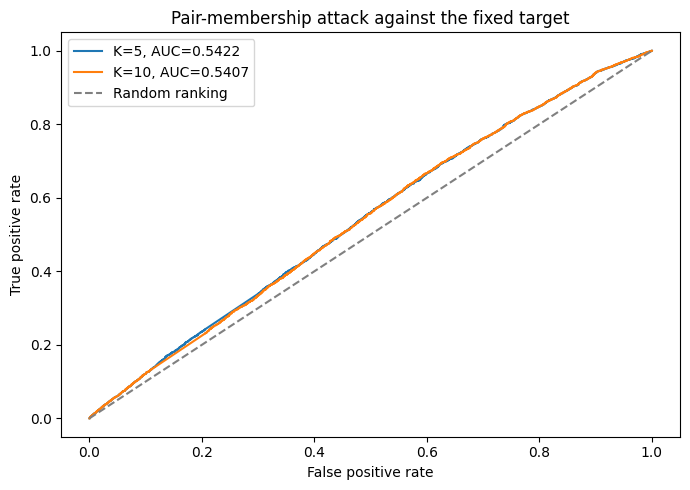


Attack comparison:
 K  attack_training_examples  accuracy  precision   recall       f1  roc_auc
 5                     67200  0.527753   0.518268 0.787351 0.625081 0.542242
10                    134400  0.527902   0.518305 0.790030 0.625951 0.540738

Saved to: C:\Users\fayya\OneDrive\Documents\GitHub\COMP3850\Group-63-COMP3850\k_runs\main_20260920_230533\attack_evaluation


In [16]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# Load the completed experiment explicitly.
experiment_dir = Path("k_runs") / "main_20260920_230533"
shadows = pd.read_csv(experiment_dir / "combined_shadow_outputs.csv")
target = pd.read_csv(
    experiment_dir / "target" / "membership_outputs.csv"
)

evaluation_dir = experiment_dir / "attack_evaluation"
evaluation_dir.mkdir(parents=True, exist_ok=True)

assert set(shadows["shadow_id"]) == set(range(1, 11))
assert not shadows.duplicated(["shadow_id", "embedding_row"]).any()
assert not target["embedding_row"].duplicated().any()

for frame in (shadows, target):
    assert not frame[["p_match", "membership"]].isna().any().any()
    assert frame["p_match"].between(0, 1).all()
    assert set(frame["membership"]) == {0, 1}

# Prediction-only features; no IDs or true linkage labels.
def membership_features(frame):
    p = np.clip(frame["p_match"].to_numpy(), 1e-7, 1 - 1e-7)
    confidence = np.maximum(p, 1 - p)
    entropy = -(p * np.log(p) + (1 - p) * np.log(1 - p))
    return np.column_stack([p, confidence, entropy])

X_target = membership_features(target)
y_target_membership = target["membership"].to_numpy()
results = []
prediction_table = target.copy()

plt.figure(figsize=(7, 5))

for k in (5, 10):
    training = shadows.loc[shadows["shadow_id"] <= k]

    attack = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42)
    )
    attack.fit(
        membership_features(training),
        training["membership"]
    )

    scores = attack.predict_proba(X_target)[:, 1]
    predictions = (scores >= 0.5).astype(int)
    matrix = confusion_matrix(
        y_target_membership, predictions, labels=[0, 1]
    )

    metrics = {
        "K": k,
        "attack_training_examples": len(training),
        "target_evaluation_examples": len(target),
        "membership_threshold": 0.5,
        "accuracy": float(accuracy_score(y_target_membership, predictions)),
        "precision": float(precision_score(
            y_target_membership, predictions, zero_division=0
        )),
        "recall": float(recall_score(
            y_target_membership, predictions, zero_division=0
        )),
        "f1": float(f1_score(
            y_target_membership, predictions, zero_division=0
        )),
        "roc_auc": float(roc_auc_score(y_target_membership, scores)),
        "true_negative": int(matrix[0, 0]),
        "false_positive": int(matrix[0, 1]),
        "false_negative": int(matrix[1, 0]),
        "true_positive": int(matrix[1, 1]),
    }
    results.append(metrics)

    joblib.dump(attack, evaluation_dir / f"attack_K{k}.joblib")
    prediction_table[f"membership_score_K{k}"] = scores
    prediction_table[f"predicted_membership_K{k}"] = predictions

    fpr, tpr, thresholds = roc_curve(y_target_membership, scores)
    pd.DataFrame({
        "false_positive_rate": fpr,
        "true_positive_rate": tpr,
        "threshold": thresholds
    }).to_csv(evaluation_dir / f"roc_K{k}.csv", index=False)

    plt.plot(fpr, tpr, label=f"K={k}, AUC={metrics['roc_auc']:.4f}")
    print(f"\nK={k} confusion matrix:\n{matrix}")

plt.plot([0, 1], [0, 1], "--", color="grey", label="Random ranking")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Pair-membership attack against the fixed target")
plt.legend()
plt.tight_layout()
plt.savefig(evaluation_dir / "target_attack_ROC.png", dpi=180)
plt.show()

summary = pd.DataFrame(results)
summary.to_csv(evaluation_dir / "K_comparison.csv", index=False)
prediction_table.to_csv(
    evaluation_dir / "target_attack_predictions.csv", index=False
)

(evaluation_dir / "evaluation_settings.json").write_text(
    json.dumps({
        "features": ["p_match", "max_class_probability", "binary_entropy"],
        "attack": "StandardScaler + LogisticRegression",
        "threshold": 0.5,
        "membership_unit": "pair",
        "target_used_for_attack_fitting": False,
        "comparison": "first 5 versus all 10 shadows",
        "limitation": "Individual record IDs overlap across data pools."
    }, indent=2),
    encoding="utf-8"
)

print("\nAttack comparison:")
print(summary[
    ["K", "attack_training_examples", "accuracy",
     "precision", "recall", "f1", "roc_auc"]
].to_string(index=False))

print("\nSaved to:", evaluation_dir.resolve())

In [17]:
audit_rows = []

for name in ["target"] + [f"shadow_{i}" for i in range(1, 11)]:
    folder = experiment_dir / name
    splits = np.load(folder / "split_indices.npz", allow_pickle=False)
    predictions = pd.read_csv(folder / "membership_outputs.csv")

    train_ids = set(splits["train"])
    heldout_ids = set(splits["heldout"])
    members = set(splits["members"])
    nonmembers = set(splits["nonmembers"])

    assert train_ids.isdisjoint(heldout_ids), name
    assert members <= train_ids, name
    assert nonmembers <= heldout_ids, name
    assert members.isdisjoint(nonmembers), name

    assert not predictions["embedding_row"].duplicated().any(), name
    assert set(predictions["membership"]) == {0, 1}, name
    assert predictions["p_match"].between(0, 1).all(), name

    assert set(predictions.loc[
        predictions["membership"] == 1, "embedding_row"
    ]) == members, name

    assert set(predictions.loc[
        predictions["membership"] == 0, "embedding_row"
    ]) == nonmembers, name

    audit_rows.append({
        "model": name,
        "training_pairs": len(train_ids),
        "heldout_pairs": len(heldout_ids),
        "member_queries": len(members),
        "nonmember_queries": len(nonmembers),
        "membership_checks": "passed"
    })

audit = pd.DataFrame(audit_rows)
audit.to_csv(experiment_dir / "membership_audit.csv", index=False)
print(audit.to_string(index=False))

    model  training_pairs  heldout_pairs  member_queries  nonmember_queries membership_checks
   target           22400           9600            6720               6720            passed
 shadow_1           22400           9600            6720               6720            passed
 shadow_2           22400           9600            6720               6720            passed
 shadow_3           22400           9600            6720               6720            passed
 shadow_4           22400           9600            6720               6720            passed
 shadow_5           22400           9600            6720               6720            passed
 shadow_6           22400           9600            6720               6720            passed
 shadow_7           22400           9600            6720               6720            passed
 shadow_8           22400           9600            6720               6720            passed
 shadow_9           22400           9600            6720    

In [18]:
import tensorflow as tf
import joblib

reload_results = []

for name in ["target"] + [f"shadow_{i}" for i in range(1, 11)]:
    folder = experiment_dir / name
    saved = pd.read_csv(folder / "membership_outputs.csv")

    # Check examples from both membership classes.
    sample = saved.groupby("membership", group_keys=False).sample(
        n=32, random_state=42
    )
    indices = sample["embedding_row"].to_numpy(dtype=int)

    source = "target" if name == "target" else "shadow"
    a = np.load(
        f"Embeddings/x1_{source}_train.npy",
        mmap_mode="r", allow_pickle=False
    )
    b = np.load(
        f"Embeddings/x2_{source}_train.npy",
        mmap_mode="r", allow_pickle=False
    )

    encoder_check = tf.keras.models.load_model(
        folder / "encoder.keras", compile=False
    )
    head_check = tf.keras.models.load_model(
        folder / "linkage_head.keras", compile=False
    )

    features = np.abs(
        encoder_check.predict(a[indices], verbose=0)
        - encoder_check.predict(b[indices], verbose=0)
    )
    reproduced = head_check.predict(features, verbose=0).ravel()

    np.testing.assert_allclose(
        reproduced, sample["p_match"].to_numpy(),
        rtol=1e-4, atol=1e-5,
        err_msg=f"{name}: reloaded predictions differ"
    )

    reload_results.append({
        "model": name,
        "examples_checked": len(sample),
        "reload_check": "passed"
    })
    del encoder_check, head_check, a, b

# Check both saved attack pipelines against their saved scores.
saved_attacks = pd.read_csv(
    evaluation_dir / "target_attack_predictions.csv"
)
for k in (5, 10):
    attack_check = joblib.load(evaluation_dir / f"attack_K{k}.joblib")
    reproduced = attack_check.predict_proba(
        membership_features(saved_attacks)
    )[:, 1]

    np.testing.assert_allclose(
        reproduced, saved_attacks[f"membership_score_K{k}"],
        rtol=1e-6, atol=1e-8
    )
    reload_results.append({
        "model": f"attack_K{k}",
        "examples_checked": len(saved_attacks),
        "reload_check": "passed"
    })

reload_report = pd.DataFrame(reload_results)
reload_report.to_csv(experiment_dir / "reload_checks.csv", index=False)
print(reload_report.to_string(index=False))

     model  examples_checked reload_check
    target                64       passed
  shadow_1                64       passed
  shadow_2                64       passed
  shadow_3                64       passed
  shadow_4                64       passed
  shadow_5                64       passed
  shadow_6                64       passed
  shadow_7                64       passed
  shadow_8                64       passed
  shadow_9                64       passed
 shadow_10                64       passed
 attack_K5             13440       passed
attack_K10             13440       passed
